# Time Series Properties

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('../data/processed_data.csv')

In [4]:
# Stationarity (ADF test)

from statsmodels.tsa.stattools import adfuller

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    
    print(f"ADF Test: {name}")
    print(f"Test Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    
    if result[1] < 0.05:
        print("→ Reject H0 (stationary)\n")
    else:
        print("→ Fail to reject H0 (non-stationary)\n")


# Running for prices
for col in df.columns:
    adf_test(df[col], col)

log_returns = np.log(df / df.shift(1))

# Running for returns
for col in log_returns.columns:
    adf_test(log_returns[col], col + " (returns)")

ADF Test: gurkor
Test Statistic: 0.7347
p-value: 0.9905
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: guitars
Test Statistic: -2.0512
p-value: 0.2646
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: slingshots
Test Statistic: -0.9229
p-value: 0.7803
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: stocks
Test Statistic: -2.3006
p-value: 0.1718
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: sugar
Test Statistic: -1.9218
p-value: 0.3219
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: water
Test Statistic: 0.7871
p-value: 0.9914
Critical Values:
   1%: -3.4316
   5%: -2.8621
   10%: -2.5671
→ Fail to reject H0 (non-stationary)

ADF Test: tranquillity
Test Statistic: -2.2412
p-va

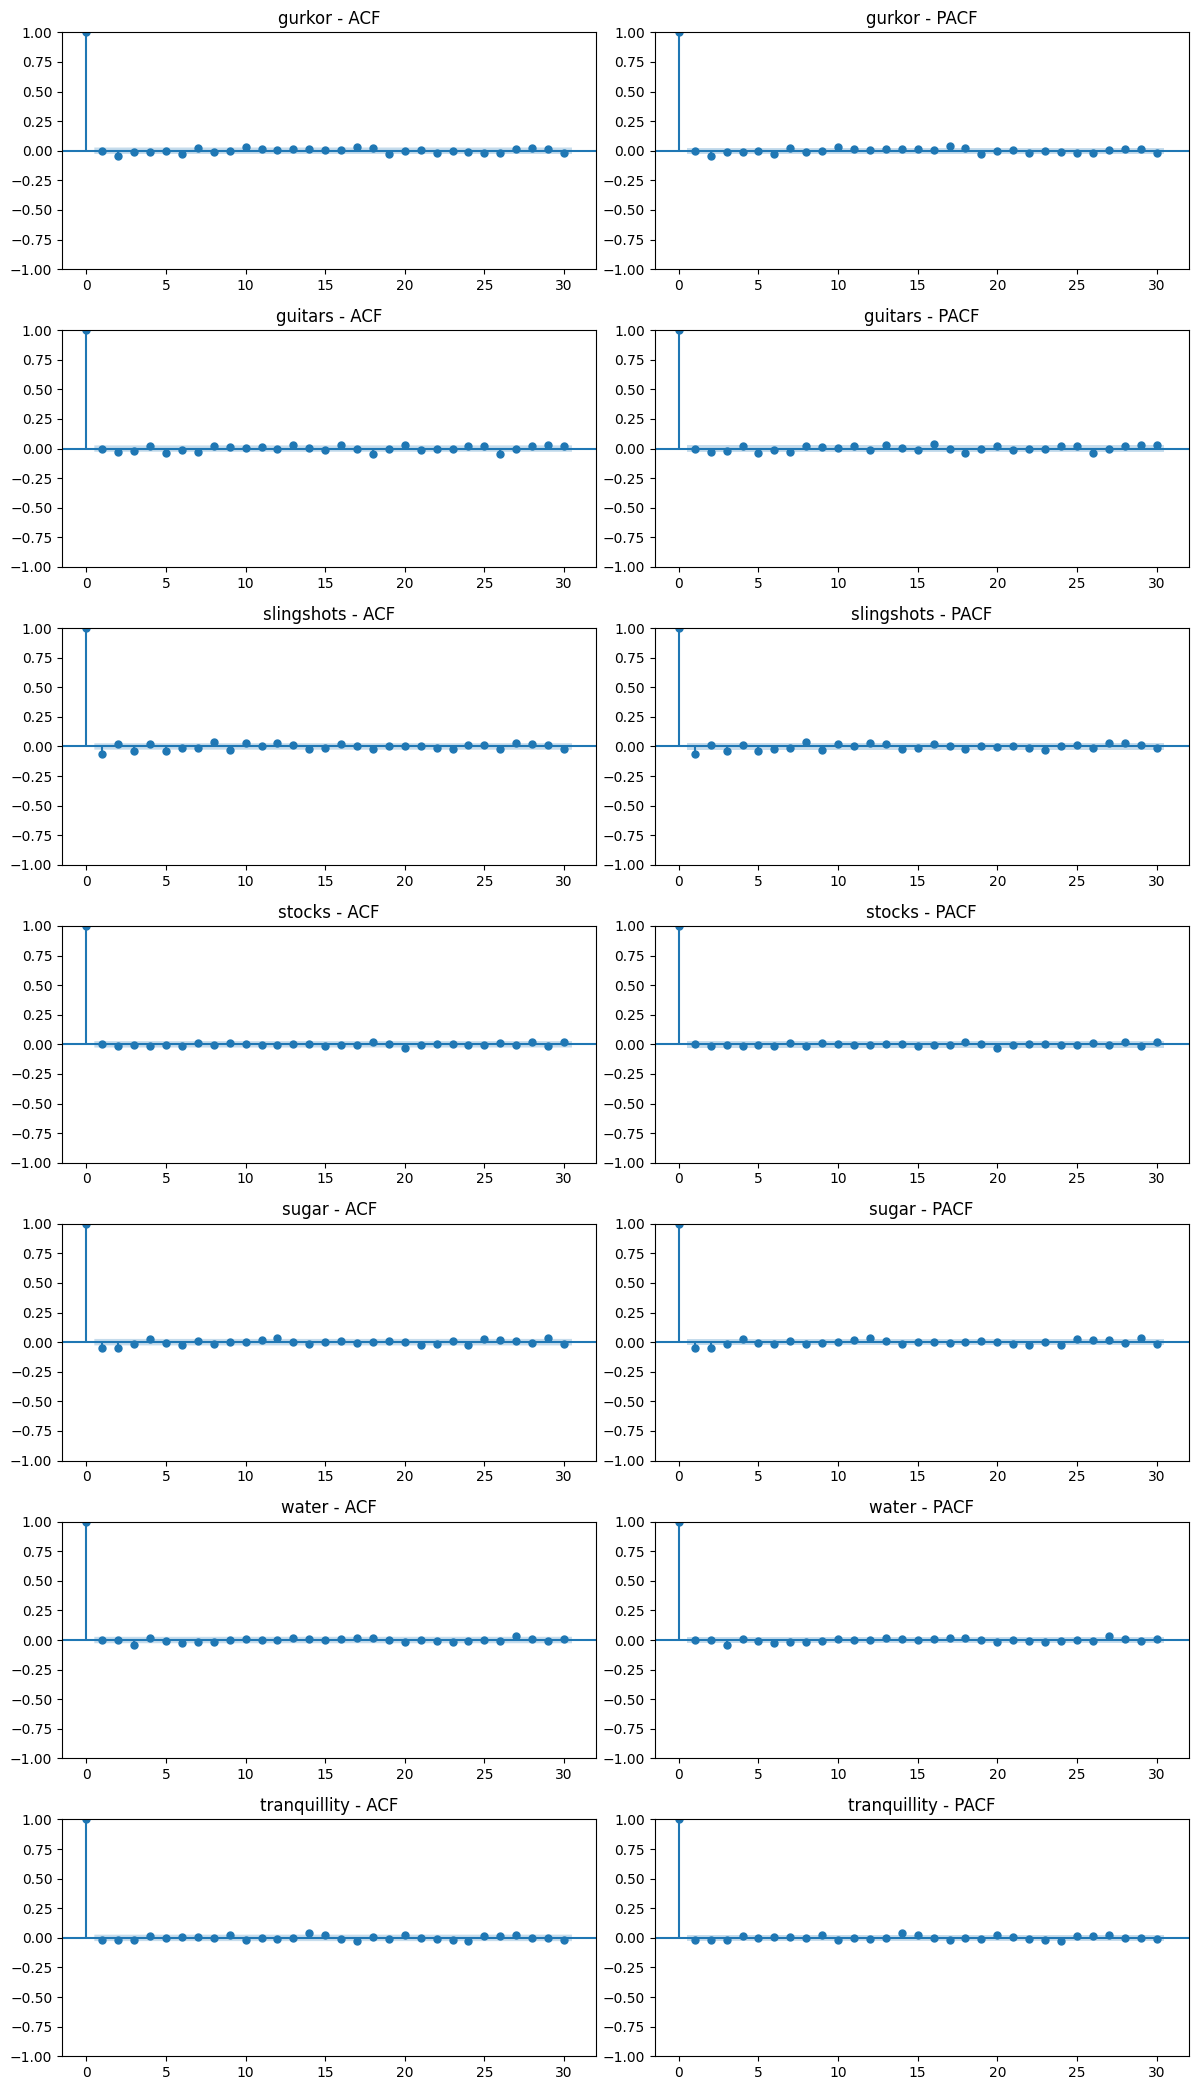

In [5]:
# ACF and PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import matplotlib.pyplot as plt

n = len(log_returns.columns)
fig, axes = plt.subplots(n, 2, figsize=(12, 3*n))

if n == 1:
    axes = [axes]

for i, col in enumerate(log_returns.columns):
    plot_acf(log_returns[col].dropna(), ax=axes[i][0], lags=30)
    plot_pacf(log_returns[col].dropna(), ax=axes[i][1], lags=30)
    
    axes[i][0].set_title(f"{col} - ACF")
    axes[i][1].set_title(f"{col} - PACF")

plt.tight_layout()
plt.show()

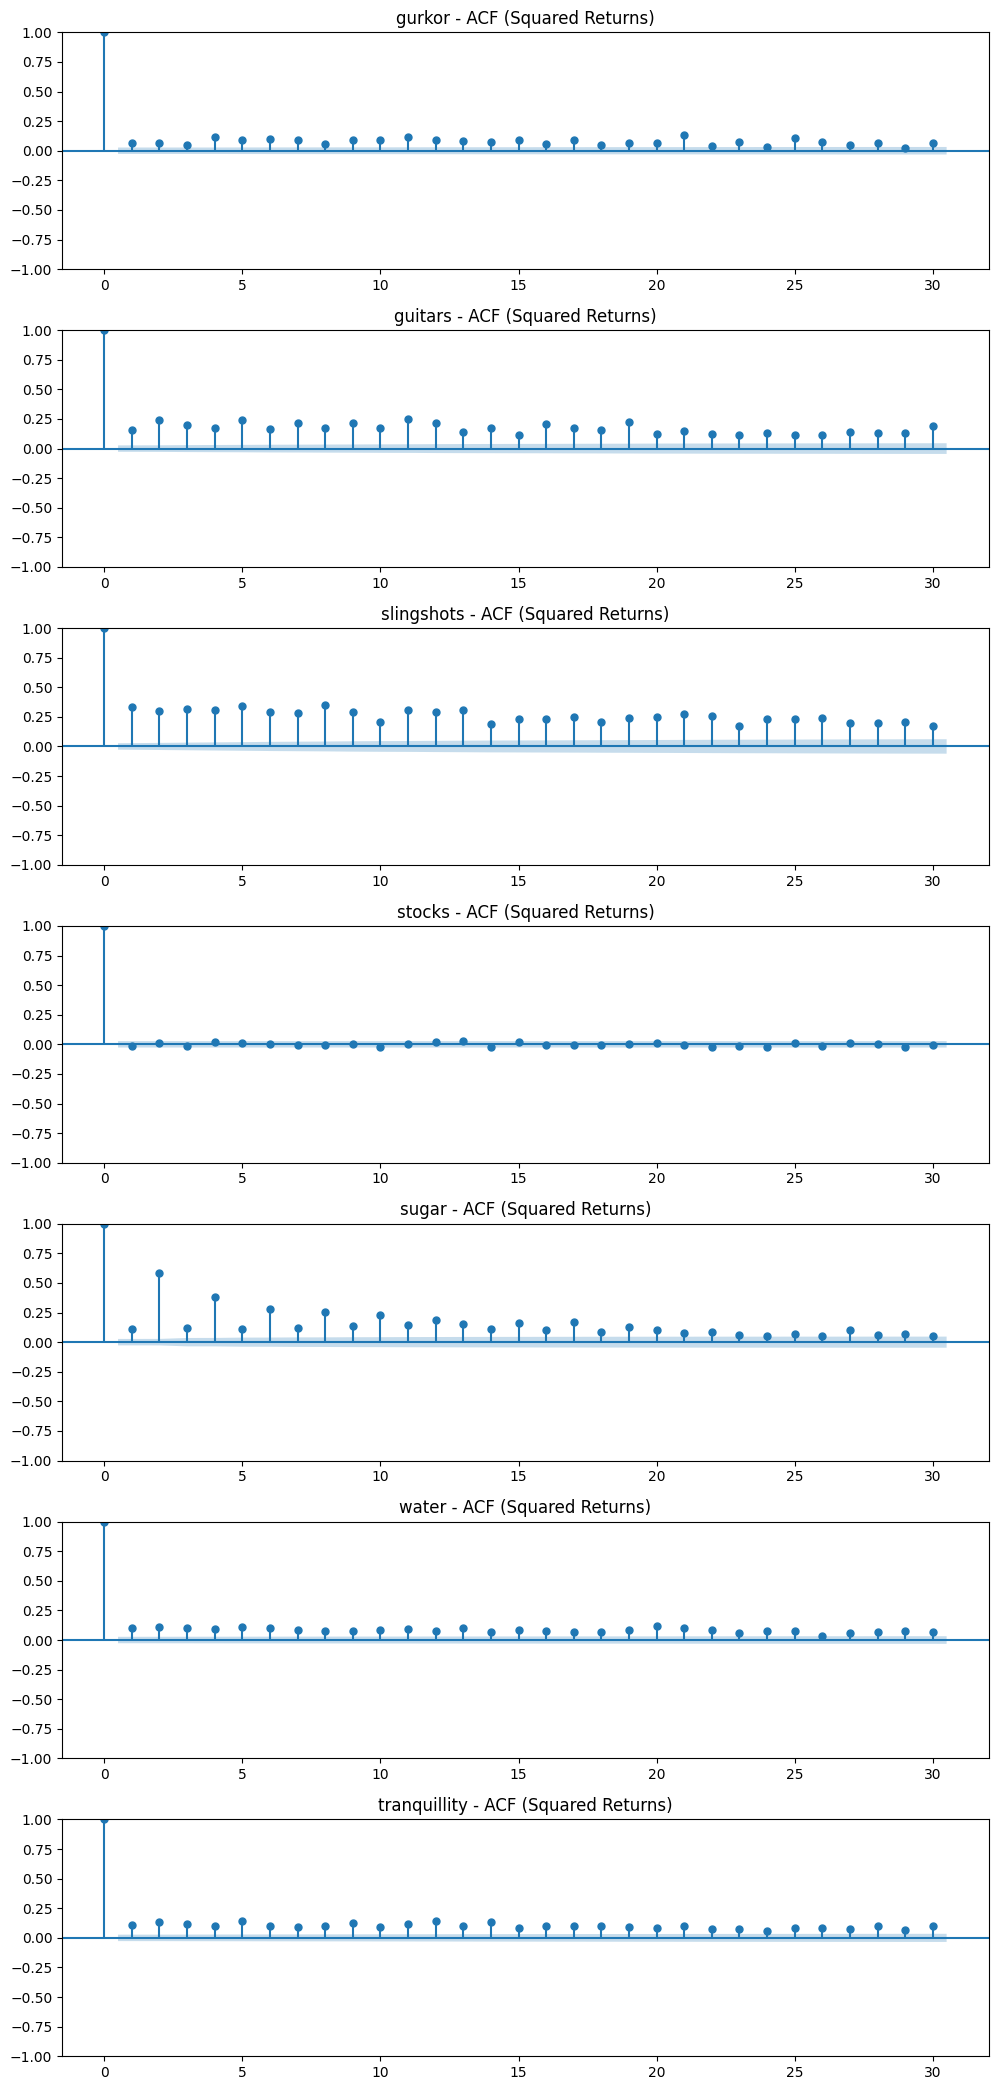

In [6]:
squared_returns = log_returns**2

n = len(squared_returns.columns)
fig, axes = plt.subplots(n, 1, figsize=(10, 3*n))

if n == 1:
    axes = [axes]

for ax, col in zip(axes, squared_returns.columns):
    plot_acf(squared_returns[col].dropna(), ax=ax, lags=30)
    ax.set_title(f"{col} - ACF (Squared Returns)")

plt.tight_layout()
plt.show()

## Analysis

The ADF tests confirm that all price series are non-stationary, as the null hypothesis of a unit root cannot be rejected. This is consistent with financial theory, where asset prices are often modeled as random walks. In contrast, all return series are strongly stationary, with p-values effectively equal to zero, indicating that returns fluctuate around a stable mean.

The autocorrelation and partial autocorrelation functions of returns show no significant serial dependence, indicating that returns behave approximately as white noise. This suggests that past returns provide little predictive power for future returns.

While raw returns show little autocorrelation, the squared returns exhibit significant and persistent autocorrelation for several assets, indicating volatility clustering. This suggests that large price movements tend to be followed by large movements, and small movements by small ones.

The strength of volatility clustering varies across assets. In particular, slingshots, guitars, and sugar exhibit strong persistence in volatility, whereas the stock series shows little evidence of such behavior. This suggests that different assets may require different modeling approaches.

The time series analysis reveals several important properties of the data. All price series are non-stationary, consistent with a random walk behavior, while the return series are strongly stationary. The return series exhibit little to no autocorrelation, suggesting that returns are largely unpredictable in their mean.

However, the squared returns display significant autocorrelation for several assets, indicating volatility clustering and time-varying variance. This behavior is particularly pronounced for slingshots, guitars, and sugar, suggesting the presence of conditional heteroskedasticity.

These findings imply that while simple linear models may suffice for modeling mean dynamics, more advanced models such as ARCH/GARCH are likely necessary to capture the volatility structure of the data.